In [1]:
from path import Path 
from scipy.stats import pearsonr, spearmanr, wilcoxon

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import scanpy as sc
import seaborn as sns
import sklearn

import os, warnings
warnings.filterwarnings('ignore')
import stan

figsize = stan.figsize
fontsize = stan.fontsize
dpi = 300

## Breast

In [2]:
id_list = {'CID4290': 'ER_1', 'CID4535': 'ER_2', 'CID44971': 'TNBC_4',
           'CID4465': 'TNBC_3', '1142243F': 'TNBC_1', '1160920F': 'TNBC_2'}
sample_list = id_list.keys()
method_list = ['DeepST', 'SpaMask', 'STAGATE']

adatas = dict() # input of STAN
for sample_id in sample_list:
    adata = stan.read_breast_wu("data/Breast_Wu/{}.h5ad".format(sample_id))
    for method in method_list:
        adata.obs[method] = pd.read_csv(f'cluster/{method}_{sample_id}.csv', index_col=0).astype('category')
    # adata.obs['DeepST'] = pd.read_csv(f'cluster/DeepST_{sample_id}.csv', index_col=0)
    # adata.obs['SpaMask'] = pd.read_csv(f'cluster/SpaMask_{sample_id}.csv', index_col=0)
    # adata.obs['STAGATE'] = pd.read_csv(f'cluster/STAGATE_{sample_id}.csv', index_col=0)
    adatas[sample_id] = adata

In [3]:
df_ari = pd.DataFrame(index=sample_list, columns=method_list)
for sample_id in sample_list:
    df_obs = adatas[sample_id].obs.dropna()
    for method in method_list:
        df_ari.loc[sample_id, method] = sklearn.metrics.adjusted_rand_score(df_obs[method], df_obs['pathology'])

In [4]:
df_ari

,DeepST,SpaMask,STAGATE
CID4290,-0.007994,0.087073,0.260634
CID4535,0.281925,0.116649,0.352185
CID44971,0.522094,0.426477,0.587509
CID4465,-0.006163,0.025956,0.021452
1142243F,0.003929,-0.002574,0.001354
1160920F,0.137043,0.232586,0.194293


Text(0.5, 1.0, 'STAGATE (ARI=0.5875)')

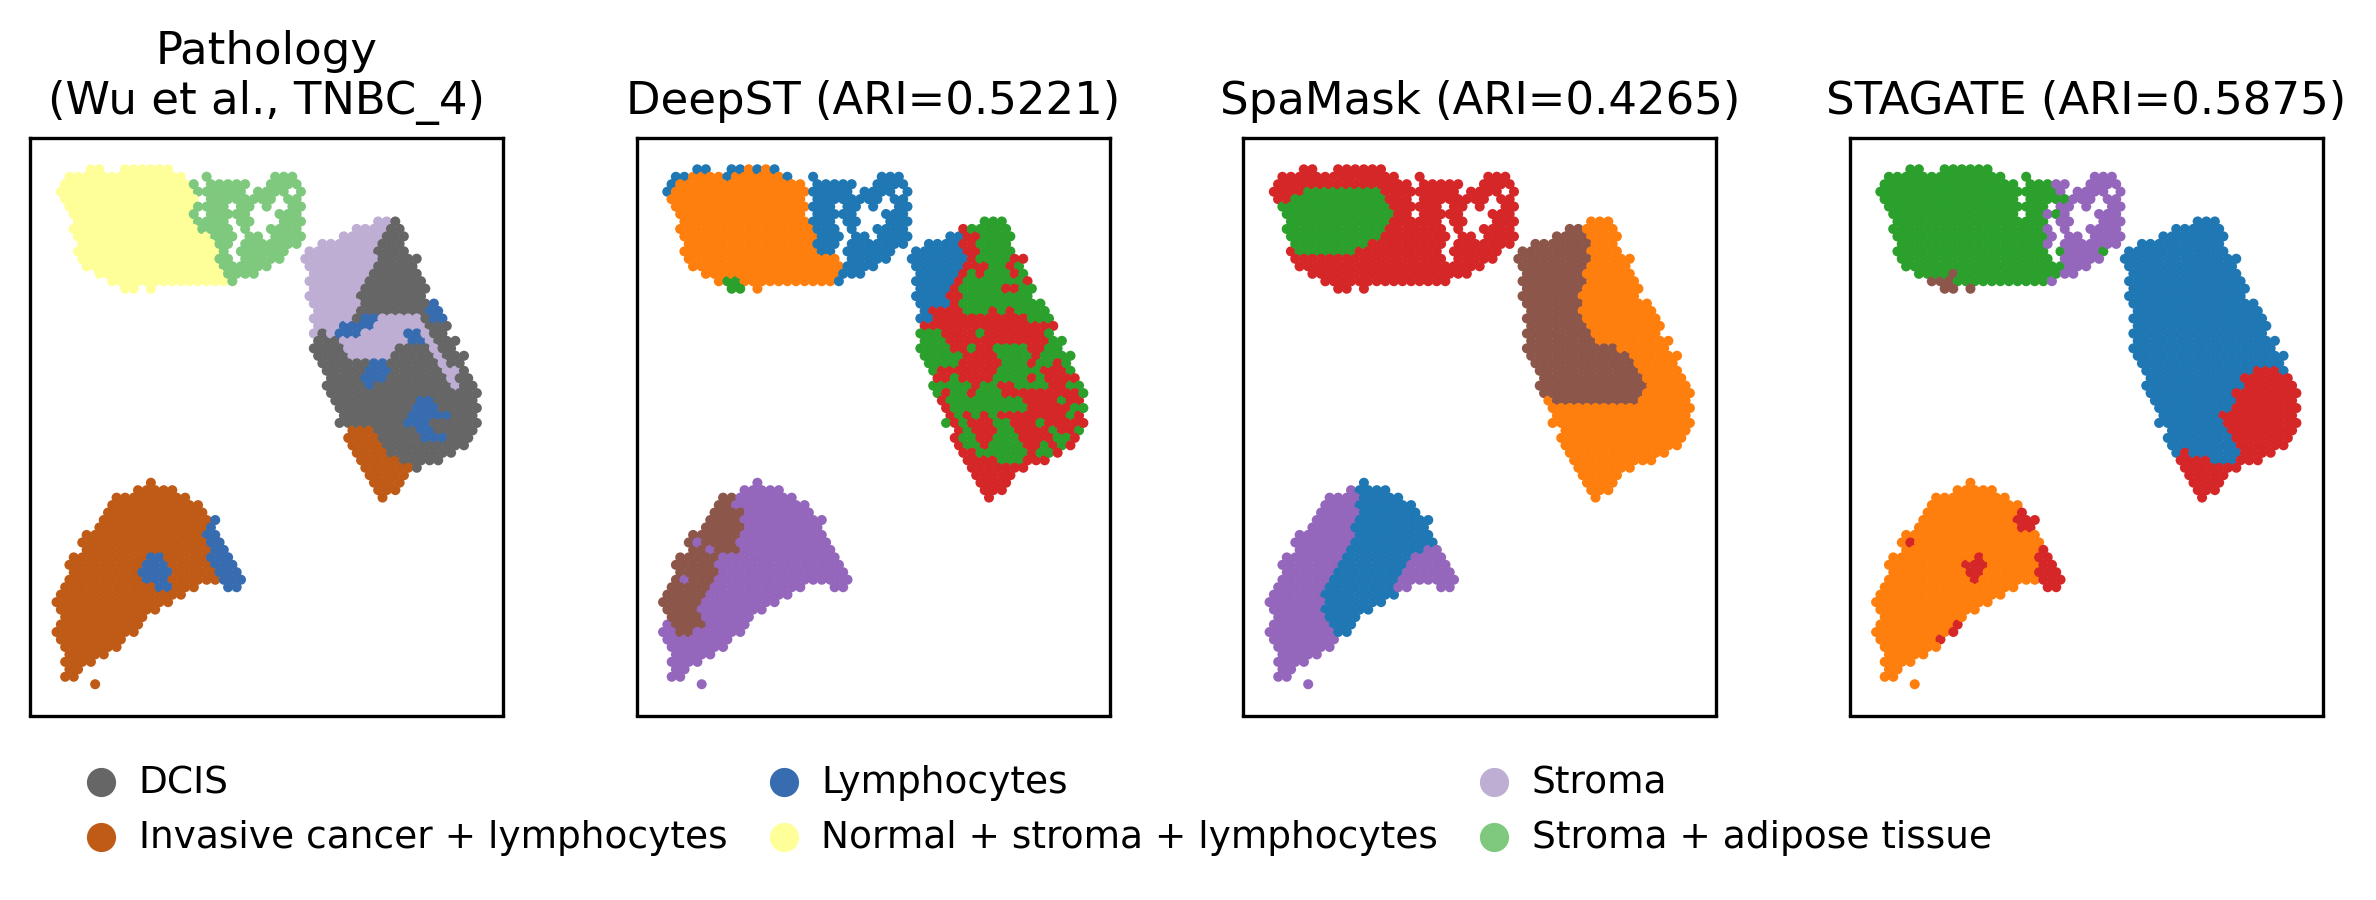

In [5]:
sample_id = 'CID44971'
fig, axes = plt.subplots(1,4, figsize=(4*figsize, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 
sc.pl.spatial(adatas[sample_id], ax=axes[0], color='pathology', palette='Accent_r', alpha_img=0, size=1.8, 
              show=False, title=f'Pathology\n(Wu et al., {id_list[sample_id]})', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[1], color='DeepST', alpha_img=0, size=1.8, 
              show=False, title='DeepST', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[2], color='SpaMask', alpha_img=0, size=1.8, 
              show=False, title='SpaMask', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[3], color='STAGATE', alpha_img=0, size=1.8, 
              show=False, title='STAGATE', legend_fontsize=fontsize, na_in_legend=False)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    
for i in [1,2,3]:
    axes[i].legend().remove()
    
axes[0].legend(title='', loc='lower left', bbox_to_anchor=(0, -0.3), columnspacing=0.5, ncol=3, handletextpad=0, frameon=False)
axes[1].set_title(f"DeepST (ARI={df_ari.loc[sample_id, 'DeepST']:.4f})")
axes[2].set_title(f"SpaMask (ARI={df_ari.loc[sample_id, 'SpaMask']:.4f})")
axes[3].set_title(f"STAGATE (ARI={df_ari.loc[sample_id, 'STAGATE']:.4f})")

In [ ]:
sample_id = 'CID44971'
fig, axes = plt.subplots(1,3, figsize=(2.7*figsize, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 
sc.pl.spatial(adatas[sample_id], ax=axes[0], color='DeepST', alpha_img=0, size=1.8, 
              show=False, title='DeepST', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[1], color='SpaMask', alpha_img=0, size=1.8, 
              show=False, title='SpaMask', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[2], color='STAGATE', alpha_img=0, size=1.8, 
              show=False, title='STAGATE', legend_fontsize=fontsize, na_in_legend=False)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    
for i in [0,1]:
    axes[i].legend().remove()
    
axes[2].legend(title=f'Wu et al.\n{id_list[sample_id]}', loc='upper right', bbox_to_anchor=(1.5, 1.05), columnspacing=0.5, handletextpad=0, frameon=False)
axes[0].set_title(f"DeepST (ARI={df_ari.loc[sample_id, 'DeepST']:.4f})")
axes[1].set_title(f"SpaMask (ARI={df_ari.loc[sample_id, 'SpaMask']:.4f})")
axes[2].set_title(f"STAGATE (ARI={df_ari.loc[sample_id, 'STAGATE']:.4f})")

In [ ]:
sample_id = '1160920F'
fig, axes = plt.subplots(1,3, figsize=(3*figsize, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 
sc.pl.spatial(adatas[sample_id], ax=axes[0], color='DeepST', alpha_img=0, size=1.8, 
              show=False, title='DeepST', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[1], color='SpaMask', alpha_img=0, size=1.8, 
              show=False, title='SpaMask', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[2], color='STAGATE', alpha_img=0, size=1.8, 
              show=False, title='STAGATE', legend_fontsize=fontsize, na_in_legend=False)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    
for i in [0,1]:
    axes[i].legend().remove()
    
axes[2].legend(title=f'Wu et al.\n{id_list[sample_id]}', loc='upper right', bbox_to_anchor=(1.5, 1.05), 
               columnspacing=0.5, ncol=2, handletextpad=0, frameon=False)
axes[0].set_title(f"DeepST (ARI={df_ari.loc[sample_id, 'DeepST']:.4f})")
axes[1].set_title(f"SpaMask (ARI={df_ari.loc[sample_id, 'SpaMask']:.4f})")
axes[2].set_title(f"STAGATE (ARI={df_ari.loc[sample_id, 'STAGATE']:.4f})")

In [ ]:
sample_id = 'CID4465'
fig, axes = plt.subplots(1,3, figsize=(2.7*figsize, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 
sc.pl.spatial(adatas[sample_id], ax=axes[0], color='DeepST', alpha_img=0, size=1.8, 
              show=False, title='DeepST', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[1], color='SpaMask', alpha_img=0, size=1.8, 
              show=False, title='SpaMask', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[2], color='STAGATE', alpha_img=0, size=1.8, 
              show=False, title='STAGATE', legend_fontsize=fontsize, na_in_legend=False)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    
for i in [0,1]:
    axes[i].legend().remove()
    
axes[2].legend(title=f'Wu et al.\n{id_list[sample_id]}', loc='upper right', bbox_to_anchor=(1.6, 0.9), 
               columnspacing=0.5, handletextpad=0, frameon=False)
axes[0].set_title(f"DeepST (ARI={df_ari.loc[sample_id, 'DeepST']:.4f})")
axes[1].set_title(f"SpaMask (ARI={df_ari.loc[sample_id, 'SpaMask']:.4f})")
axes[2].set_title(f"STAGATE (ARI={df_ari.loc[sample_id, 'STAGATE']:.4f})")

In [ ]:
sample_id = 'CID4290'
fig, axes = plt.subplots(1,3, figsize=(2.7*figsize, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 
sc.pl.spatial(adatas[sample_id], ax=axes[0], color='DeepST', alpha_img=0, size=1.8, 
              show=False, title='DeepST', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[1], color='SpaMask', alpha_img=0, size=1.8, 
              show=False, title='SpaMask', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[2], color='STAGATE', alpha_img=0, size=1.8, 
              show=False, title='STAGATE', legend_fontsize=fontsize, na_in_legend=False)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    
for i in [0,1]:
    axes[i].legend().remove()
    
axes[2].legend(title=f'Wu et al.\n{id_list[sample_id]}', loc='upper right', bbox_to_anchor=(1.6, 0.9), 
               columnspacing=0.5, handletextpad=0, frameon=False)
axes[0].set_title(f"DeepST (ARI={df_ari.loc[sample_id, 'DeepST']:.4f})")
axes[1].set_title(f"SpaMask (ARI={df_ari.loc[sample_id, 'SpaMask']:.4f})")
axes[2].set_title(f"STAGATE (ARI={df_ari.loc[sample_id, 'STAGATE']:.4f})")

In [ ]:
sample_id = 'CID4535'
fig, axes = plt.subplots(1,3, figsize=(2.7*figsize, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 
sc.pl.spatial(adatas[sample_id], ax=axes[0], color='DeepST', alpha_img=0, size=1.8, 
              show=False, title='DeepST', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[1], color='SpaMask', alpha_img=0, size=1.8, 
              show=False, title='SpaMask', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[2], color='STAGATE', alpha_img=0, size=1.8, 
              show=False, title='STAGATE', legend_fontsize=fontsize, na_in_legend=False)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    
for i in [0,1]:
    axes[i].legend().remove()
    
axes[2].legend(title=f'Wu et al.\n{id_list[sample_id]}', loc='upper right', bbox_to_anchor=(1.65, 0.9), 
               columnspacing=0.5, ncol=2, handletextpad=0, frameon=False)
axes[0].set_title(f"DeepST (ARI={df_ari.loc[sample_id, 'DeepST']:.4f})")
axes[1].set_title(f"SpaMask (ARI={df_ari.loc[sample_id, 'SpaMask']:.4f})")
axes[2].set_title(f"STAGATE (ARI={df_ari.loc[sample_id, 'STAGATE']:.4f})")

In [ ]:
sample_id = '1142243F'
fig, axes = plt.subplots(1,3, figsize=(3*figsize, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 
sc.pl.spatial(adatas[sample_id], ax=axes[0], color='DeepST', alpha_img=0, size=1.8, 
              show=False, title='DeepST', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[1], color='SpaMask', alpha_img=0, size=1.8, 
              show=False, title='SpaMask', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adatas[sample_id], ax=axes[2], color='STAGATE', alpha_img=0, size=1.8, 
              show=False, title='STAGATE', legend_fontsize=fontsize, na_in_legend=False)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    
for i in [0,1]:
    axes[i].legend().remove()
    
axes[2].legend(title=f'Wu et al.\n{id_list[sample_id]}', loc='upper right', bbox_to_anchor=(1.5, 1.05), 
               columnspacing=0.5, handletextpad=0, frameon=False)
axes[0].set_title(f"DeepST (ARI={df_ari.loc[sample_id, 'DeepST']:.4f})")
axes[1].set_title(f"SpaMask (ARI={df_ari.loc[sample_id, 'SpaMask']:.4f})")
axes[2].set_title(f"STAGATE (ARI={df_ari.loc[sample_id, 'STAGATE']:.4f})")

## Lymphnode

In [6]:
sample_id = "V1_Human_Lymph_Node"
adata = stan.read_visium_sge(sample_id=sample_id, min_cells=5, min_counts=5000)
adata = stan.annotate_lymphnode(adata, fpath="resources/lymphnode_annotation")
for method in method_list:
    adata.obs[method] = pd.read_csv(f'cluster/{method}_lymphnode.csv', index_col=0).astype('category')

In [7]:
adata

AnnData object with n_obs × n_vars = 3989 × 21261
    obs: 'in_tissue', 'array_row', 'array_col', 'n_counts', 'germinal_center', 'DeepST', 'SpaMask', 'STAGATE'
    var: 'gene_ids', 'feature_types', 'genome', 'n_cells'
    uns: 'spatial'
    obsm: 'spatial', 'celltype', 'celltype_raw'
    layers: 'raw'

In [8]:
from sklearn.preprocessing import OrdinalEncoder
def compute_ari(adata, cluster_1, cluster_2, cluster1_target):
    label_1 = np.array(adata.obs[cluster_1]).reshape(-1,1)
    label_1[label_1!=cluster1_target]='0'
    sklearn_encoder = OrdinalEncoder()
    encoder_1 = sklearn_encoder.fit_transform(label_1)

    label_2 = np.array(adata.obs[cluster_2]).reshape(-1,1)
    sklearn_encoder = OrdinalEncoder()
    encoder_2 = sklearn_encoder.fit_transform(label_2)

    s = sklearn.metrics.adjusted_rand_score(encoder_1.flatten(), encoder_2.flatten())
    return s

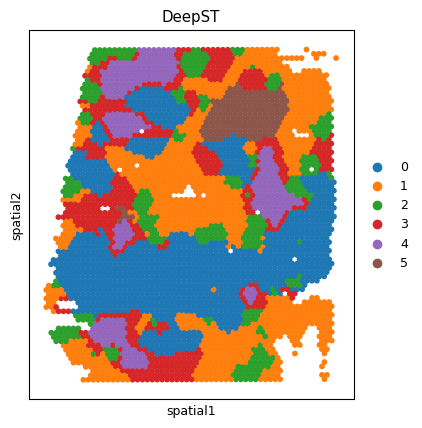

In [9]:
sc.pl.spatial(adata, color='DeepST', alpha_img=0, size=1.8)

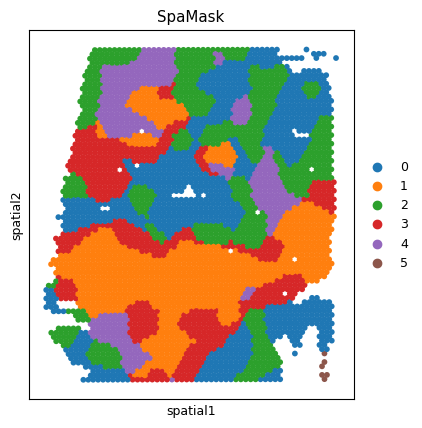

In [10]:
sc.pl.spatial(adata, color='SpaMask', alpha_img=0, size=1.8)

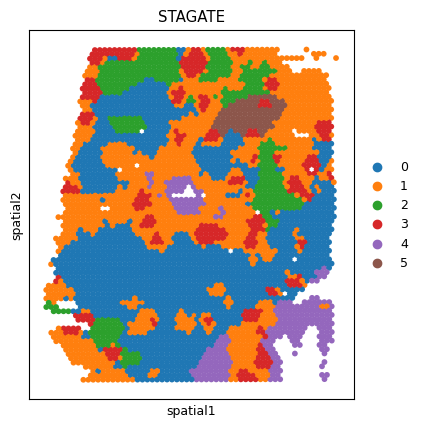

In [11]:
sc.pl.spatial(adata, color='STAGATE', alpha_img=0, size=1.8)

In [15]:
df_obs = adata.obs.dropna()
df_ari.loc['lymphnode', 'DeepST'] = compute_ari(adata, 'DeepST', 'germinal_center', 2)
df_ari.loc['lymphnode', 'SpaMask'] = compute_ari(adata, 'SpaMask', 'germinal_center', 2)
df_ari.loc['lymphnode', 'STAGATE'] = compute_ari(adata, 'STAGATE', 'germinal_center', 3)

In [16]:
df_ari

,DeepST,SpaMask,STAGATE
CID4290,-0.007994,0.087073,0.260634
CID4535,0.281925,0.116649,0.352185
CID44971,0.522094,0.426477,0.587509
CID4465,-0.006163,0.025956,0.021452
1142243F,0.003929,-0.002574,0.001354
1160920F,0.137043,0.232586,0.194293
lymphnode,0.698883,0.378225,0.811899


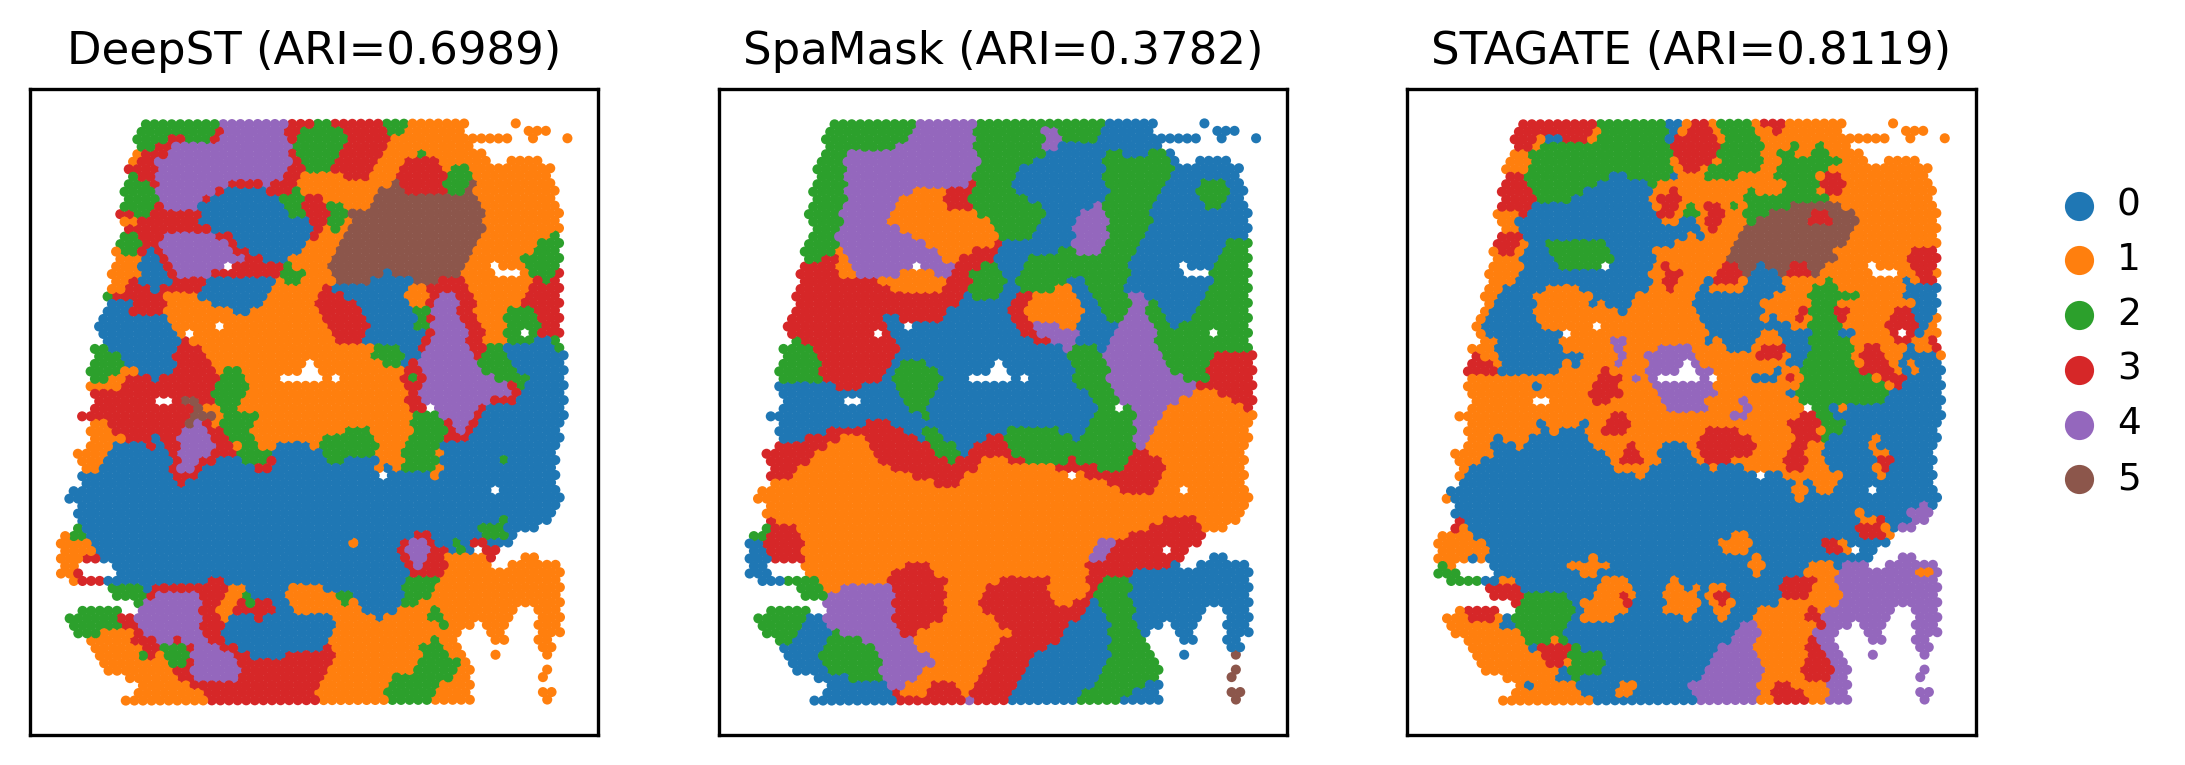

In [17]:
fig, axes = plt.subplots(1,3, figsize=(figsize*3, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 
sc.pl.spatial(adata, ax=axes[0], color='DeepST', alpha_img=0, size=1.8, 
              show=False, title='DeepST', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adata, ax=axes[1], color='SpaMask', alpha_img=0, size=1.8, 
              show=False, title='SpaMask', legend_fontsize=fontsize, na_in_legend=False)
sc.pl.spatial(adata, ax=axes[2], color='STAGATE', alpha_img=0, size=1.8, 
              show=False, title='STAGATE', legend_fontsize=fontsize, na_in_legend=False)

for ax in axes:
    ax.set_xlabel("")
    ax.set_ylabel("")
    
for i in [0,1]:
    axes[i].legend().remove()
    
axes[2].legend(title='', loc='upper right', bbox_to_anchor=(1.35, 0.9), 
               columnspacing=0.5, handletextpad=0, frameon=False)
axes[0].set_title(f"DeepST (ARI={df_ari.loc['lymphnode', 'DeepST']:.4f})")
axes[1].set_title(f"SpaMask (ARI={df_ari.loc['lymphnode', 'SpaMask']:.4f})")
axes[2].set_title(f"STAGATE (ARI={df_ari.loc['lymphnode', 'STAGATE']:.4f})")

plt.tight_layout(pad=0.6)

In [ ]:
fig, axes = plt.subplots(1,4, figsize=(figsize*4, figsize), dpi=dpi)
plt.rc('font', size=fontsize) 

i=0
sc.pl.spatial(adata_tfa_scaled, color="leiden", size=1.8, alpha_img=0, ax=axes[i], 
              show=False, frameon=True, legend_fontsize=fontsize)
axes[i].set_title(f"STAN (ARI={df.iloc[i,-1]:.4f})")

i=1
sc.pl.spatial(adata_tfa_ridge_scaled, color="leiden", size=1.8, alpha_img=0, ax=axes[i], 
              show=False, frameon=True, legend_fontsize=fontsize)
axes[i].set_title(f"Ridge (ARI={df.iloc[i,-1]:.4f})")

i=2
sc.pl.spatial(adata_dec_scaled, color="leiden", size=1.8, alpha_img=0, ax=axes[i], 
              show=False, frameon=True, legend_fontsize=fontsize)
axes[i].set_title(f"DecoupleR (ARI={df.iloc[i,-1]:.4f})")

i=3
sc.pl.spatial(adata_scaled_subset, color="leiden", size=1.8, alpha_img=0, ax=axes[i], 
              show=False, frameon=True, legend_fontsize=fontsize)
axes[i].set_title(f"TF mRNA (ARI={df.iloc[i,-1]:.4f})")

for i in range(4):
    axes[i].set_ylabel(axes[i].get_ylabel(),labelpad=-1)
    axes[i].set_xlabel(axes[i].get_xlabel(),labelpad=-1)
    
for i in range(3):
    axes[i].legend().remove()

plt.tight_layout(pad=0.6)